In [3]:
%reload_ext autoreload
%autoreload 2

In [4]:
from PDESolver import *

In [5]:
# Declaration of necessary variables
f = Function('f')
g = Function('g')

# Symbol manipulation

## Symbol analysis

In [6]:
from sympy import symbols
x, xi = symbols('x xi', real=True)
expr = (1 + x**2)*xi + 1/xi

p = PseudoDifferentialOperator(expr=expr, vars_x=[x], mode='symbol')

p.interactive_symbol_analysis(
                            xlim=(-2, 2),
                            xi_range=(0.1, 5),
                            density=100)



symbol = 
  ⎛ 2    ⎞   1
ξ⋅⎝x  + 1⎠ + ─
             ξ


interactive(children=(Dropdown(description='Mode:', options=('Group Velocity Field', 'Micro-Support (1/|p|)', …

In [7]:
from sympy import symbols

x, y, xi, eta = symbols('x y xi eta', real=True)

expr_2d = ((1 + x**2 + y**2)*(xi**2 + eta**2) + x*eta - y*xi) / (1 + xi**2 + eta**2)

p2d = PseudoDifferentialOperator(expr=expr_2d, vars_x=[x, y], mode='symbol')

p2d.interactive_symbol_analysis(
                            xlim=(-2, 2),
                            ylim=(-2, 2),
                            xi_range=(-5, 5),
                            eta_range=(-5, 5),
                            density=50)



symbol = 
            ⎛ 2    2⎞ ⎛ 2    2    ⎞
η⋅x - ξ⋅y + ⎝η  + ξ ⎠⋅⎝x  + y  + 1⎠
───────────────────────────────────
             2    2                
            η  + ξ  + 1            


interactive(children=(Dropdown(description='Mode:', options=('Group Velocity Field', 'Micro-Support (1/|p|)', …

### Singularity Flow

In [8]:
from sympy import symbols, sin, cos
x, xi = symbols('x xi', real=True)
expr = xi**3 + sin(x) * xi

op = PseudoDifferentialOperator(expr=expr, vars_x=[x], mode='symbol')
ani = op.animate_singularity(xi0=2.0, tmax=10.0)
ani


symbol = 
 3           
ξ  + ξ⋅sin(x)


In [9]:
from sympy import symbols
x, y, xi, eta = symbols('x y xi eta', real=True)
expr2d = x * eta - y * xi

op2 = PseudoDifferentialOperator(expr=expr2d, vars_x=[x, y], mode='symbol')
ani = op2.animate_singularity(xi0=2.0, eta0=0.0, projection='frequency')
ani


symbol = 
η⋅x - ξ⋅y


In [10]:
ani = op2.animate_singularity(xi0=0.0, eta0=2.0, projection='position')
ani

## Homogeneous principal symbol of the operator

In [11]:
from sympy import symbols
x, xi = symbols('x xi')
xi = symbols('xi', real=True, positive=True)

p_ordre_1 = xi**2 + 1
p = PseudoDifferentialOperator(expr=p_ordre_1, vars_x=[x], mode='symbol')
print(p.principal_symbol(order=1))  
print(p.principal_symbol(order=2))


symbol = 
 2    
ξ  + 1
xi**2 + 1
xi**2 + 1


In [12]:
from sympy import symbols
x, y, xi, eta = symbols('x y xi eta')
xi = symbols('xi', real=True, positive=True)
eta = symbols('eta', real=True, positive=True)

p_ordre_1 = xi**2 + eta**2 + 1
p = PseudoDifferentialOperator(expr=p_ordre_1, vars_x=[x], mode='symbol')
print(p.principal_symbol(order=1))  
print(p.principal_symbol(order=2))


symbol = 
 2    2    
η  + ξ  + 1
eta**2 + xi**2 + 1
eta**2 + xi**2 + 1


## Order (degree of homogeneity) of the symbol

In [13]:
from sympy import symbols
x, xi = symbols('x xi', real=True)
op = PseudoDifferentialOperator(expr=xi**2 + x, vars_x=[x], mode='symbol')
order = op.symbol_order()
print("1D Estimated order:", order)




symbol = 
     2
x + ξ 
1D Estimated order: 2


In [14]:
x, y, xi, eta = symbols('x y xi eta', real=True)
op2d = PseudoDifferentialOperator(expr=xi**2 + eta**2 + x + y, vars_x=[x, y], mode='symbol')
order = op2d.symbol_order()
print("2D Estimated order: ", order)



symbol = 
 2        2    
η  + x + ξ  + y
2D Estimated order:  2


## Asymptotic expansion

In [15]:
from sympy import symbols, exp
x, xi = symbols('x xi', real=True)

expr = exp(x*xi / (x**2 + xi**2))
p = PseudoDifferentialOperator(expr=expr, vars_x=[x], mode='symbol')
print(p.asymptotic_expansion(order=4))


symbol = 
   x⋅ξ  
 ───────
  2    2
 x  + ξ 
ℯ       
-5*x**3/(6*xi**3) + x**2/(2*xi**2) + x/xi + 1


In [16]:
from sympy import symbols
x, y, xi, eta = symbols('x y xi eta', real=True, positive=True)

p_ordre_1 = sqrt(xi**2 + eta**2) + 1/xi
p = PseudoDifferentialOperator(expr=p_ordre_1, vars_x=[x, y], mode='symbol')

print(p.asymptotic_expansion(order=4))



symbol = 
   _________    
  ╱  2    2    1
╲╱  η  + ξ   + ─
               ξ
sqrt(eta**2 + xi**2) + 1/xi


## Asymptotic composition

In [17]:
from sympy import symbols
x, xi = symbols('x xi')
p1 = PseudoDifferentialOperator(expr=xi + x, vars_x=[x], mode='symbol')

p2 = PseudoDifferentialOperator(expr=xi + x**2, vars_x=[x], mode='symbol')

composition_1d = p1.compose_asymptotic(p2, order=2)
print("1D Asymptotic composition:")
print(composition_1d)



symbol = 
x + ξ

symbol = 
 2    
x  + ξ
1D Asymptotic composition:
1.0*(x + xi)*(x**2 + xi)


In [18]:
x, y, xi, eta = symbols('x y xi eta')
p1 = PseudoDifferentialOperator(expr=xi**2 + eta**2 + x*y, vars_x=[x, y], mode='symbol')
p2 = PseudoDifferentialOperator(expr=xi + eta + x + y, vars_x=[x, y], mode='symbol')

composition_2d = p1.compose_asymptotic(p2, order=2)
print("2D Asymptotic composition:")
print(composition_2d)



symbol = 
 2          2
η  + x⋅y + ξ 

symbol = 
η + x + ξ + y
2D Asymptotic composition:
1.0*(eta**2 + x*y + xi**2)*(eta + x + xi + y)


## Right asymtotic inverse

In [19]:
p = PseudoDifferentialOperator(expr=xi + 1, vars_x=[x], mode='symbol')
right_inv_1d = p.right_inverse_asymptotic(order=2)
print("1D Right asymtotic inverse:")
print(right_inv_1d)
p2 = PseudoDifferentialOperator(expr=right_inv_1d, vars_x=[x], mode='symbol')
print("1D Composition rule:")
p.compose_asymptotic(p2, order=2)


symbol = 
ξ + 1
1D Right asymtotic inverse:
1/(xi + 1)

symbol = 
  1  
─────
ξ + 1
1D Composition rule:


1.00000000000000

In [20]:
p = PseudoDifferentialOperator(expr=xi + eta + 1, vars_x=[x, y], mode='symbol')
right_inv_2d = p.right_inverse_asymptotic(order=2)
print("2D Right asymtotic inverse:")
print(right_inv_2d)
p2 = PseudoDifferentialOperator(expr=right_inv_2d, vars_x=[x, y], mode='symbol')
print("2D Composition rule:")
p.compose_asymptotic(p2, order=2)


symbol = 
η + ξ + 1
2D Right asymtotic inverse:
1/(eta + xi + 1)

symbol = 
    1    
─────────
η + ξ + 1
2D Composition rule:


1.00000000000000

## Left asymtotic inverse

In [21]:
p = PseudoDifferentialOperator(expr=xi + 1, vars_x=[x], mode='symbol')
left_inv_1d = p.left_inverse_asymptotic(order=2)
print("1D Left asymtotic inverse:")
print(left_inv_1d)
p2 = PseudoDifferentialOperator(expr=left_inv_1d, vars_x=[x], mode='symbol')
print("1D Composition rule:")
p2.compose_asymptotic(p, order=2)


symbol = 
ξ + 1
1D Left asymtotic inverse:
1/(xi + 1)

symbol = 
  1  
─────
ξ + 1
1D Composition rule:


1.00000000000000

In [22]:
p = PseudoDifferentialOperator(expr=xi + eta + 1, vars_x=[x, y], mode='symbol')
left_inv_2d = p.left_inverse_asymptotic(order=3)
print("2D Left asymtotic inverse:")
print(left_inv_2d)
p2 = PseudoDifferentialOperator(expr=left_inv_2d, vars_x=[x, y], mode='symbol')
print("2D Composition rule:")
p2.compose_asymptotic(p, order=3)


symbol = 
η + ξ + 1
2D Left asymtotic inverse:
1/(eta + xi + 1)

symbol = 
    1    
─────────
η + ξ + 1
2D Composition rule:


1.00000000000000

## Ellipticity

In [23]:
x, xi = symbols('x xi', real=True)

x_vals = np.linspace(-1, 1, 100)
xi_vals = np.linspace(-10, 10, 100)

op1 = PseudoDifferentialOperator(expr=xi**2 + 1, vars_x=[x], mode='symbol')
print("1D elliptic test:", op1.is_elliptic_numerically(x_vals, xi_vals))  # True 

op2 = PseudoDifferentialOperator(expr=xi, vars_x=[x], mode='symbol')
print("1D non-elliptic test:", op2.is_elliptic_numerically(x_vals, xi_vals))  # False attendu



symbol = 
 2    
ξ  + 1
1D elliptic test: True

symbol = 
ξ
1D non-elliptic test: True


In [24]:
x_vals = np.linspace(-1, 1, 50)
y_vals = np.linspace(-1, 1, 50)
xi_vals = np.linspace(-10, 10, 50)
eta_vals = np.linspace(-10, 10, 50)

op3 = PseudoDifferentialOperator(expr=xi**2 + eta**2 + 1, vars_x=[x, y], mode='symbol')
print("2D elliptic test:", op3.is_elliptic_numerically((x_vals, y_vals), (xi_vals, eta_vals)))  # True

op4 = PseudoDifferentialOperator(expr=xi + eta, vars_x=[x, y], mode='symbol')
print("2D non-elliptic test:", op4.is_elliptic_numerically((x_vals, y_vals), (xi_vals, eta_vals)))  # False



symbol = 
 2    2    
η  + ξ  + 1
2D elliptic test: True

symbol = 
η + ξ
2D non-elliptic test: False


## $L ∘ P = Id$


symbol = 
 2    2    
x  + ξ  + 1
Left asymptotic inverse:
                                                                               ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪
                             ⎛           2                                     ↪
                             ⎜ 24.0⋅ⅈ⋅x⋅ξ         4.0⋅ⅈ⋅x            2⋅ξ       ↪
                   - 2.0⋅ⅈ⋅x⋅⎜────────────── - ────────────── - ────────────── ↪
                             ⎜             4                3                2 ↪
                             ⎜⎛ 2    2    ⎞    ⎛ 2    2    ⎞    ⎛ 2    2    ⎞  ↪
    4.0⋅ⅈ⋅x⋅ξ                ⎝⎝x  + ξ  + 1⎠    ⎝x  + ξ  + 1⎠    ⎝x  + ξ  + 1⎠  ↪
- ────────────── - ─────────────────────────────────────────────────────────── ↪
               3                                 

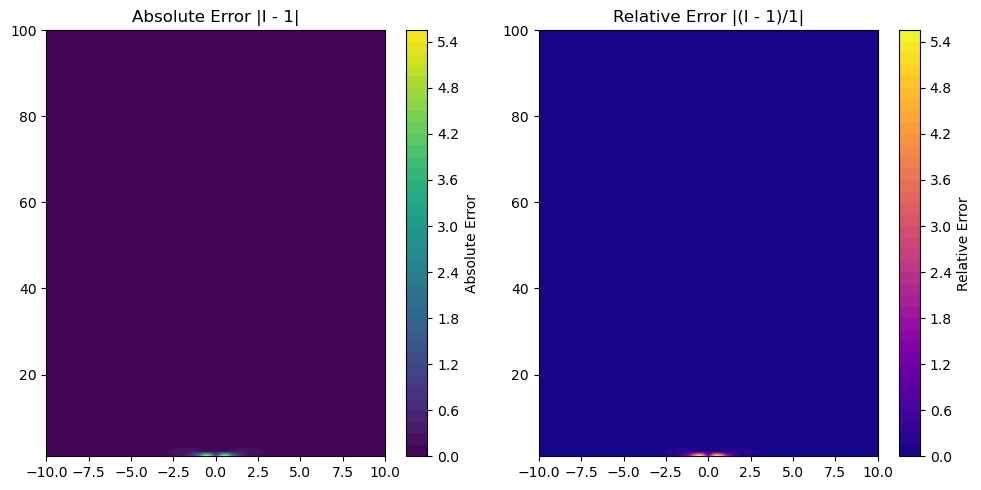

In [25]:
order = 2
# Define symbolic variables
x, xi = symbols('x xi', real=True)
u = Function('u')(x)

# Define the pseudo-differential symbol p(x, xi)
p_symbol = xi**2 + x**2 + 1

# Create the pseudo-differential operator
p = PseudoDifferentialOperator(expr=p_symbol, vars_x=[x], mode='symbol')

# Compute the left asymptotic inverse of the operator
left_inv = p.left_inverse_asymptotic(order=order)
print("Left asymptotic inverse:")
pprint(left_inv)

# Create a new operator from the left inverse
p_left_inv = PseudoDifferentialOperator(expr=left_inv, vars_x=[x], mode='symbol')

# Verify the composition rule: L ∘ P ≈ I (identity operator)
composition = p_left_inv.compose_asymptotic(p, order=order)
print("Composition rule (L ∘ P):")
pprint(composition)

# Simplify the result to check if it approximates the identity operator
identity_approximation = simplify(composition)
print("Simplified composition (should approximate 1):")
pprint(identity_approximation)

# Development around xi -> infinity
series_expansion = series(identity_approximation, xi, oo, n=3)
print("Series expansion:", series_expansion)

# Convert to numerical function
identity_func = lambdify((x, xi), identity_approximation, 'numpy')

# Grid of points
x_vals = np.linspace(-10, 10, 100)
xi_vals = np.linspace(1, 100, 100)  # Positive frequencies
X, XI = np.meshgrid(x_vals, xi_vals, indexing='ij')

# Numerical evaluation
identity_vals = identity_func(X, XI)

absolute_error = np.abs(identity_vals - 1)
relative_error = np.abs((identity_vals - 1) / 1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.contourf(X, XI, absolute_error, levels=50, cmap='viridis')
plt.colorbar(label='Absolute Error')
plt.title('Absolute Error |I - 1|')

plt.subplot(1, 2, 2)
plt.contourf(X, XI, relative_error, levels=50, cmap='plasma')
plt.colorbar(label='Relative Error')
plt.title('Relative Error |(I - 1)/1|')

plt.tight_layout()
plt.show()


## $P ∘ R = Id$


symbol = 
 2    2    
x  + ξ  + 1
Right asymptotic inverse:
                                                                               ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪
                             ⎛         2                                       ↪
                             ⎜ 24.0⋅ⅈ⋅x ⋅ξ          2⋅x            4.0⋅ⅈ⋅ξ     ↪
                   - 2.0⋅ⅈ⋅ξ⋅⎜────────────── - ────────────── - ────────────── ↪
                             ⎜             4                2                3 ↪
                             ⎜⎛ 2    2    ⎞    ⎛ 2    2    ⎞    ⎛ 2    2    ⎞  ↪
    4.0⋅ⅈ⋅x⋅ξ                ⎝⎝x  + ξ  + 1⎠    ⎝x  + ξ  + 1⎠    ⎝x  + ξ  + 1⎠  ↪
- ────────────── - ─────────────────────────────────────────────────────────── ↪
               3                                

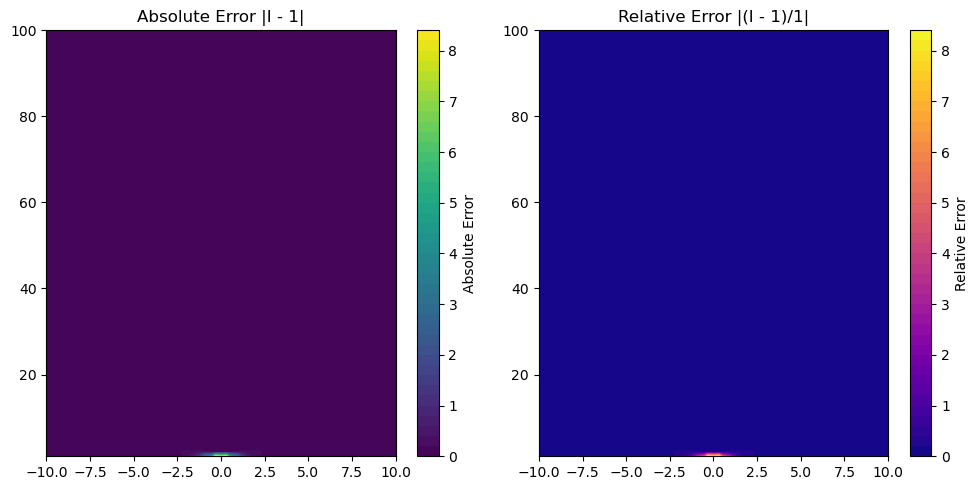

In [26]:
order = 2
# Define symbolic variables
x, xi = symbols('x xi', real=True)
u = Function('u')(x)

# Define the pseudo-differential symbol p(x, xi)
p_symbol = xi**2 + x**2 + 1

# Create the pseudo-differential operator
p = PseudoDifferentialOperator(expr=p_symbol, vars_x=[x], mode='symbol')

# Compute the left asymptotic inverse of the operator
right_inv = p.right_inverse_asymptotic(order=order)
print("Right asymptotic inverse:")
pprint(right_inv)

# Create a new operator from the left inverse
p_right_inv = PseudoDifferentialOperator(expr=right_inv, vars_x=[x], mode='symbol')

# Verify the composition rule: L ∘ P ≈ I (identity operator)
composition = p.compose_asymptotic(p_right_inv, order=order)
print("Composition rule (P ∘ R ):")
pprint(composition)

# Simplify the result to check if it approximates the identity operator
identity_approximation = simplify(composition)
print("Simplified composition (should approximate 1):")
pprint(identity_approximation)

# Development around xi -> infinity
series_expansion = series(identity_approximation, xi, oo, n=3)
print("Series expansion:", series_expansion)

# Convert to numerical function
identity_func = lambdify((x, xi), identity_approximation, 'numpy')

# Grid of points
x_vals = np.linspace(-10, 10, 100)
xi_vals = np.linspace(1, 100, 100)  # Positive frequencies
X, XI = np.meshgrid(x_vals, xi_vals, indexing='ij')

# Numerical evaluation
identity_vals = identity_func(X, XI)

absolute_error = np.abs(identity_vals - 1)
relative_error = np.abs((identity_vals - 1) / 1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.contourf(X, XI, absolute_error, levels=50, cmap='viridis')
plt.colorbar(label='Absolute Error')
plt.title('Absolute Error |I - 1|')

plt.subplot(1, 2, 2)
plt.contourf(X, XI, relative_error, levels=50, cmap='plasma')
plt.colorbar(label='Relative Error')
plt.title('Relative Error |(I - 1)/1|')

plt.tight_layout()
plt.show()


## Formal adjoint

### 1D

In [27]:
from sympy import symbols
x, xi = symbols('x xi')
xi = symbols('xi', real=True, positive=True)
x = symbols('x', real=True, positive=True)

p_ordre_1 = xi**2
p = PseudoDifferentialOperator(expr=p_ordre_1, vars_x=[x], mode='symbol')
print(p.formal_adjoint())  
print(p.is_self_adjoint())


symbol = 
 2
ξ 
xi**2
True


In [28]:
from sympy import symbols, I, exp, conjugate

# Declaration of variables
x, xi = symbols('x xi', real=True)
xi = symbols('xi', real=True, positive=True)
x = symbols('x', real=True)

# Complex symbol depending on x and xi
p_expr = (1 + I * x) * xi + exp(-x) / xi

# Creation of the pseudo-differential operator
p = PseudoDifferentialOperator(expr=p_expr, vars_x=[x], mode='symbol')

# Calculation of the formal adjoint
adjoint = p.formal_adjoint()
print("Formal adjoint (1D):")
print(adjoint)

# Self-adjointness test
print("Is self-adjoint (1D)?", p.is_self_adjoint())



symbol = 
               -x
              ℯ  
ξ⋅(ⅈ⋅x + 1) + ───
               ξ 
Formal adjoint (1D):
-I*x*xi + xi + exp(-x)/xi
Is self-adjoint (1D)? False


### 2D

In [29]:
from sympy import symbols
xi, eta = symbols('xi eta', real=True, positive=True)
x, y = symbols('x y', real=True, positive=True)

p_ordre_1 = xi**2 + eta**2
p = PseudoDifferentialOperator(expr=p_ordre_1, vars_x=[x, y], mode='symbol')
print(p.formal_adjoint())  

print(p.is_self_adjoint())





symbol = 
 2    2
η  + ξ 
eta**2 + xi**2
True


In [30]:
from sympy import symbols
xi, eta = symbols('xi eta', real=True, positive=True)
x, y = symbols('x y', real=True, positive=True)

p_ordre_1 = y * xi**2 + x * eta**2
p = PseudoDifferentialOperator(expr=p_ordre_1, vars_x=[x, y], mode='symbol')
print(p.formal_adjoint())  

print(p.is_self_adjoint())



symbol = 
 2      2  
η ⋅x + ξ ⋅y
eta**2*x + xi**2*y
True


In [31]:
from sympy import symbols, I, exp

# Declaration of variables
x, y, xi, eta = symbols('x y xi eta', real=True)
xi = symbols('xi', real=True, positive=True)
eta = symbols('eta', real=True, positive=True)
x, y = symbols('x y', real=True)

# Complex symbol in 2D
p_expr_2d = (x + I*y)*xi + (y - I*x)*eta + exp(-x - y)/(xi + eta)

# Creation of the 2D operator
p2 = PseudoDifferentialOperator(expr=p_expr_2d, vars_x=[x, y], mode='symbol')

# Calculation of the adjoint
adjoint_2d = p2.formal_adjoint()
print("Formal adjoint (2D):")
print(adjoint_2d)

# Self-adjointness test
print("Is self-adjoint (2D)?", p2.is_self_adjoint())

p2.interactive_symbol_analysis(
                            xlim=(-2, 2),
                            ylim=(-2, 2),
                            xi_range=(-5, 5),
                            eta_range=(-5, 5),
                            density=50)



symbol = 
                              -x - y
                             ℯ      
η⋅(-ⅈ⋅x + y) + ξ⋅(x + ⅈ⋅y) + ───────
                              η + ξ 
Formal adjoint (2D):
((eta + xi)*(eta*(I*x + y) + xi*(x - I*y))*exp(x + y) + 1)*exp(-x - y)/(eta + xi)
Is self-adjoint (2D)? False


interactive(children=(Dropdown(description='Mode:', options=('Group Velocity Field', 'Micro-Support (1/|p|)', …

## Kohn–Nirenberg Quantization with FFT


*********************************
* Partial differential equation *
*********************************

     ⎛ 2    2          ⎞    
psiOp⎝x  + ξ  + 1, u(x)⎠ = 0

********************
* Equation parsing *
********************


Equation rewritten in standard form: psiOp(x**2 + xi**2 + 1, u(x))
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: psiOp(x**2 + xi**2 + 1, u(x))
Analyzing term: psiOp(x**2 + xi**2 + 1, u(x))
  --> Classified as pseudo linear term (psiOp)
Final linear terms: {}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(1, x**2 + xi**2 + 1)]
Source terms: []
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

symbol = 
 2    2    
x  + ξ  + 1
For psiOp, please use the interactive_symbol_analysis method separately
Relative Error: 1.06e-08


/home/fifi/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/fifi/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


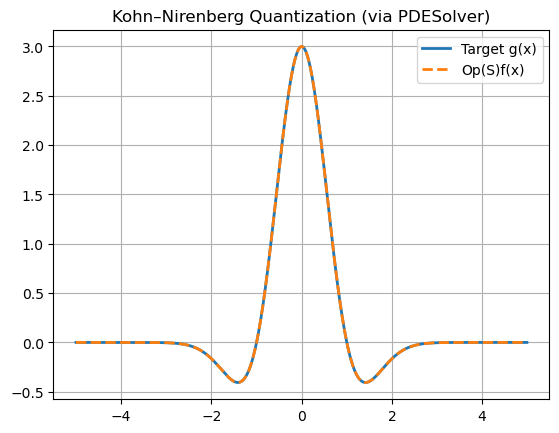

In [32]:
# --- Dummy Equation for Solver Initialization ---
x, xi = symbols('x xi', real=True)
u = Function('u')(x)

equation = Eq(psiOp(x**2 + xi**2 + 1, u), 0)

# --- Initialize Solver ---
solver = PDESolver(equation)
L = 10
N = 1024
solver.setup(Lx=L, Nx=N)

# --- Test Function and Target ---
x_grid = solver.x_grid
f_vals = np.exp(-x_grid**2)
g_vals = 3 * (1 - x_grid**2) * f_vals

# --- Symbol of the Pseudo-Op ---
def S(x, xi):
    return x**2 + xi**2 + 1

# --- Apply Pseudo-Operator ---
g_approx = solver.kohn_nirenberg_fft(f_vals, symbol_func=S)

# --- Relative Error ---
err = np.linalg.norm(g_vals - g_approx) / np.linalg.norm(g_vals)
print(f"Relative Error: {err:.2e}")

# --- Display Results ---
plt.plot(x_grid, g_vals, label='Target g(x)', lw=2)
plt.plot(x_grid, g_approx, '--', label='Op(S)f(x)', lw=2)
plt.legend()
plt.grid(True)
plt.title("Kohn–Nirenberg Quantization (via PDESolver)")
plt.show()



*********************************
* Partial differential equation *
*********************************

     ⎛ 2    2          ⎞    
psiOp⎝x  + ξ  + 1, u(x)⎠ = 0

********************
* Equation parsing *
********************


Equation rewritten in standard form: psiOp(x**2 + xi**2 + 1, u(x))
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: psiOp(x**2 + xi**2 + 1, u(x))
Analyzing term: psiOp(x**2 + xi**2 + 1, u(x))
  --> Classified as pseudo linear term (psiOp)
Final linear terms: {}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(1, x**2 + xi**2 + 1)]
Source terms: []
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

symbol = 
 2    2    
x  + ξ  + 1
For psiOp, please use the interactive_symbol_analysis method separately
Relative Error: 1.06e-08


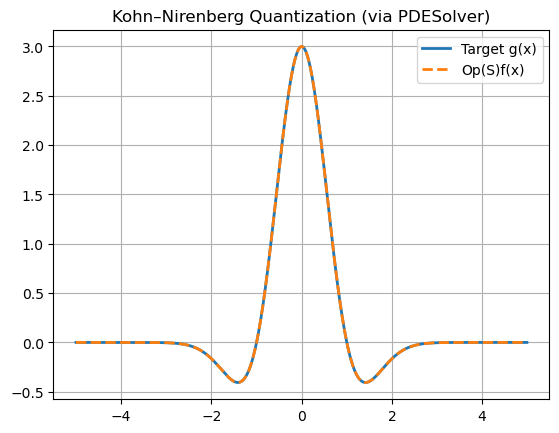

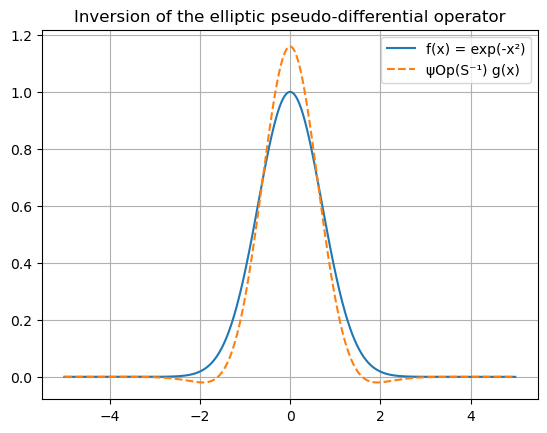

Relative error: 1.59e-01


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import Eq, symbols, Function

# --- Dummy Equation for Solver Initialization ---
x, xi = symbols('x xi', real=True)
u = Function('u')(x)

equation = Eq(psiOp(x**2 + xi**2 + 1, u), 0)

# --- Initialize Solver ---
solver = PDESolver(equation)
L = 10
N = 1024
solver.setup(Lx=L, Nx=N)

# --- Test Function and Target ---
x_grid = solver.x_grid
f_vals = np.exp(-x_grid**2)
g_vals = 3 * (1 - x_grid**2) * f_vals

# --- Symbol of the Pseudo-Op ---
def S(x, xi):
    return x**2 + xi**2 + 1

# --- Apply Pseudo-Operator ---
g_approx = solver.kohn_nirenberg_fft(f_vals, symbol_func=S)

# --- Relative Error ---
err = np.linalg.norm(g_vals - g_approx) / np.linalg.norm(g_vals)
print(f"Relative Error: {err:.2e}")

# --- Display Results ---
plt.plot(x_grid, g_vals, label='Target g(x)', lw=2)
plt.plot(x_grid, g_approx, '--', label='Op(S)f(x)', lw=2)
plt.legend()
plt.grid(True)
plt.title("Kohn–Nirenberg Quantization (via PDESolver)")
plt.show()


def S_inv(x, xi):
    return 1.0 / (S(x, xi) + 1e-10)  # Small regularization

f_approx = solver.kohn_nirenberg_fft(g_approx, S_inv)

plt.plot(x_grid, f_vals, label='f(x) = exp(-x²)')
plt.plot(x_grid, f_approx, '--', label='ψOp(S⁻¹) g(x)')
plt.legend()
plt.title("Inversion of the elliptic pseudo-differential operator")
plt.grid(True)
plt.show()

err = np.linalg.norm(f_approx - f_vals) / np.linalg.norm(f_vals)
print(f"Relative error: {err:.2e}")



*********************************
* Partial differential equation *
*********************************

     ⎛ 2    2          ⎞    
psiOp⎝x  + ξ  + 1, u(x)⎠ = 0

********************
* Equation parsing *
********************


Equation rewritten in standard form: psiOp(x**2 + xi**2 + 1, u(x))
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: psiOp(x**2 + xi**2 + 1, u(x))
Analyzing term: psiOp(x**2 + xi**2 + 1, u(x))
  --> Classified as pseudo linear term (psiOp)
Final linear terms: {}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(1, x**2 + xi**2 + 1)]
Source terms: []
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

symbol = 
 2    2    
x  + ξ  + 1
For psiOp, please use the interactive_symbol_analysis method separately


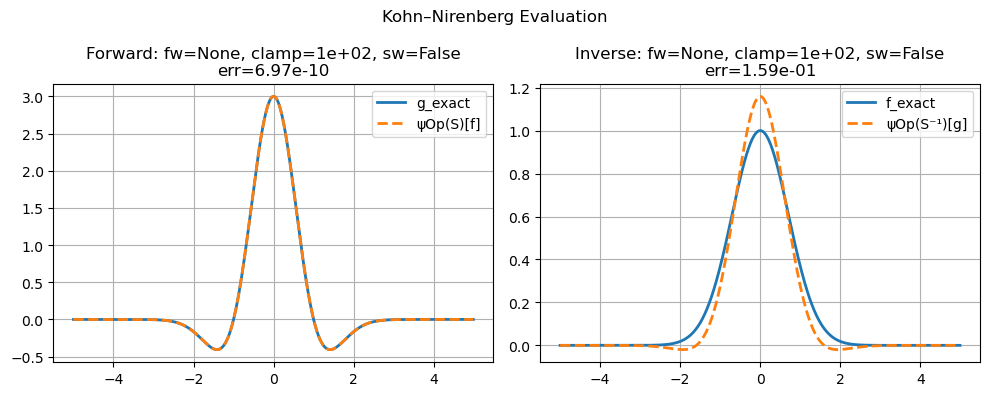

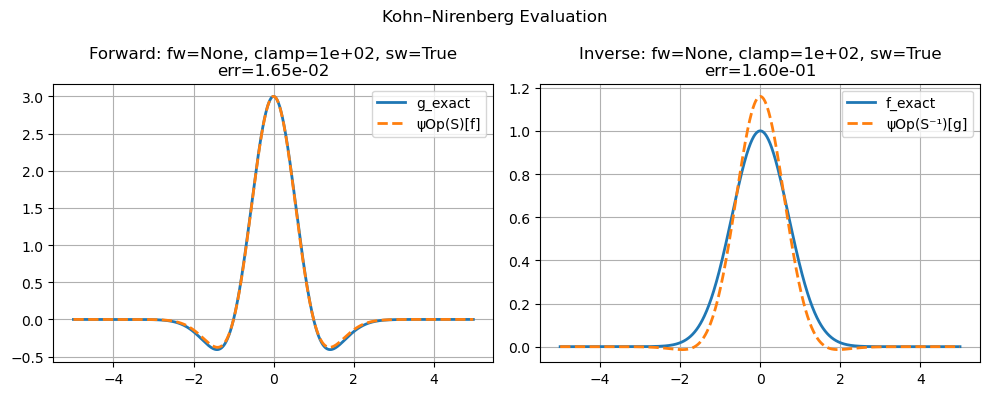

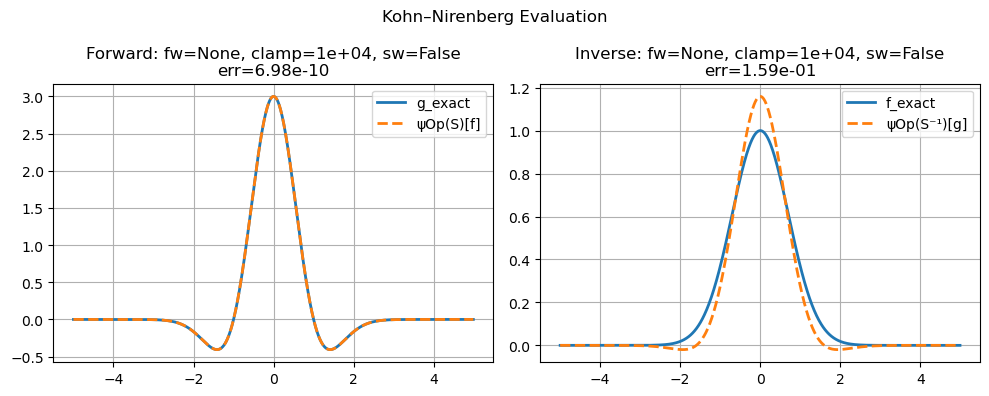

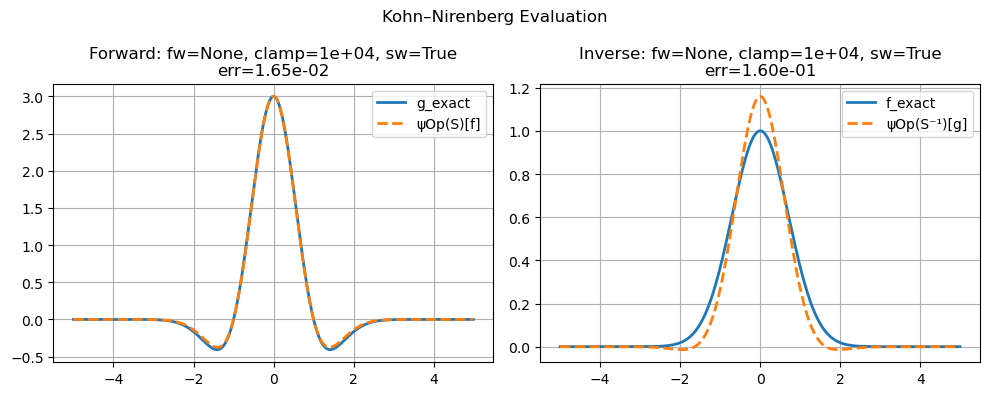

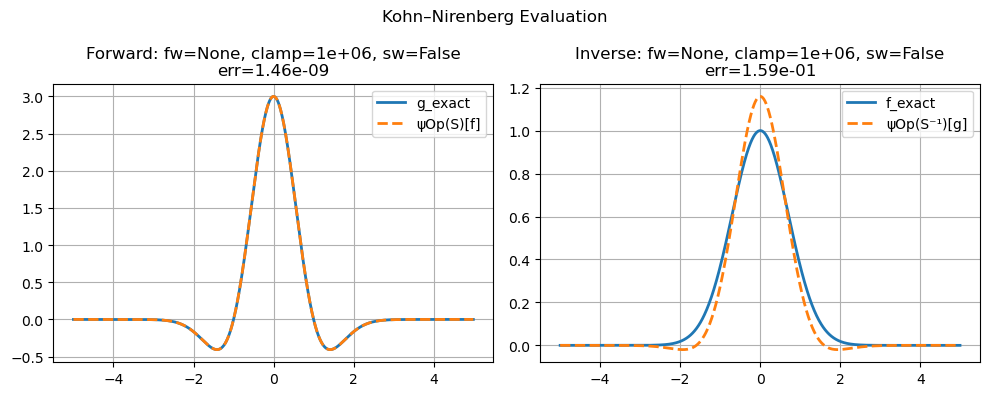

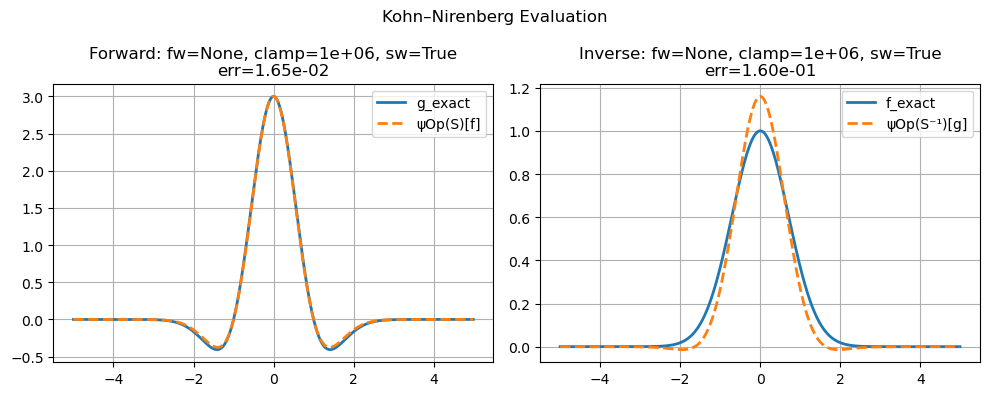

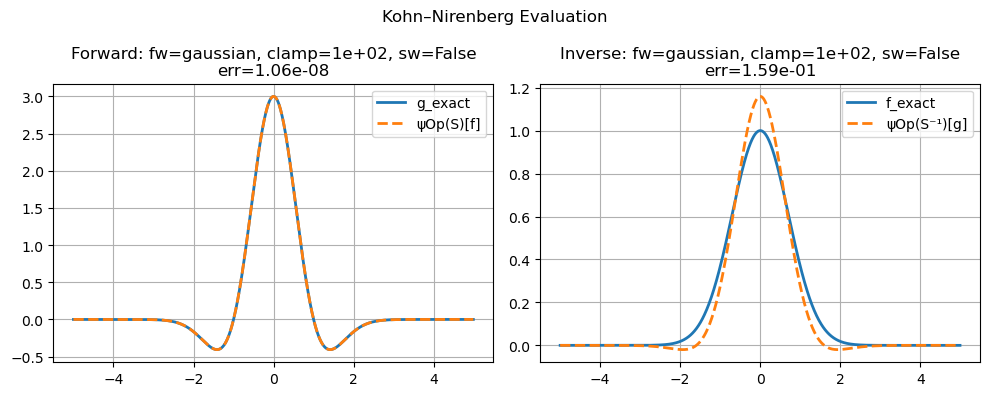

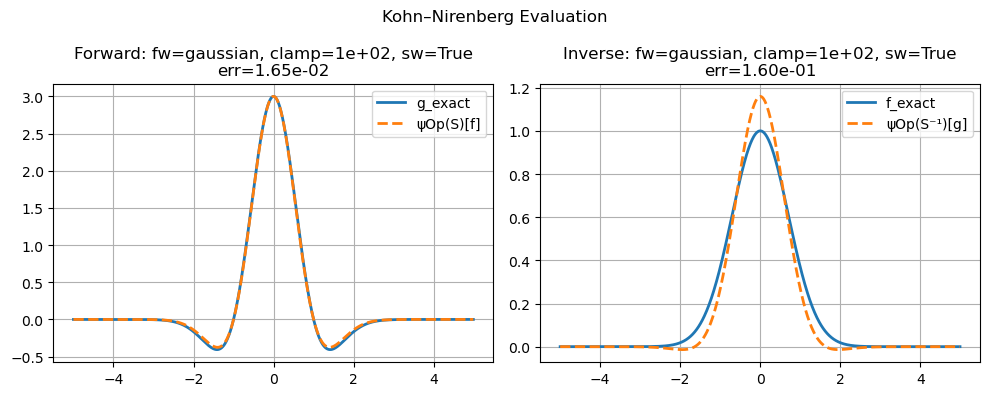

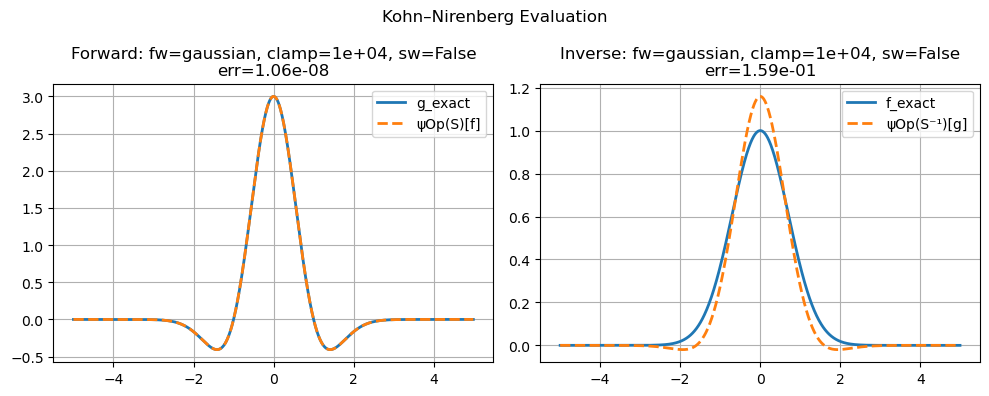

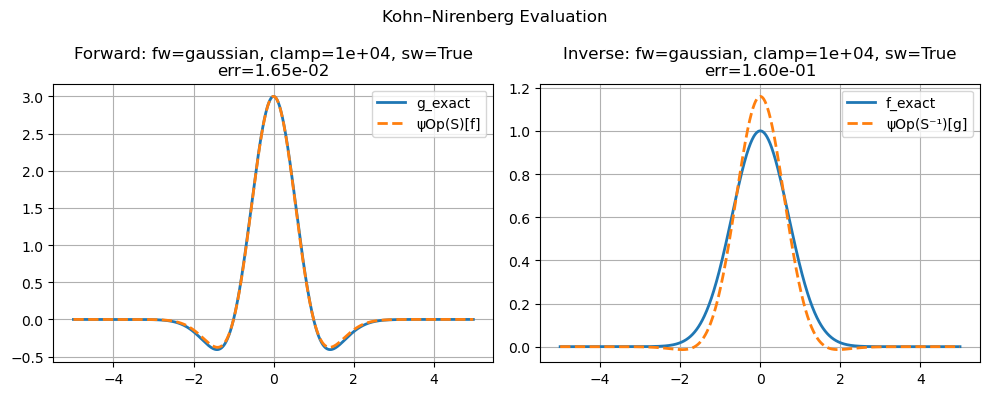

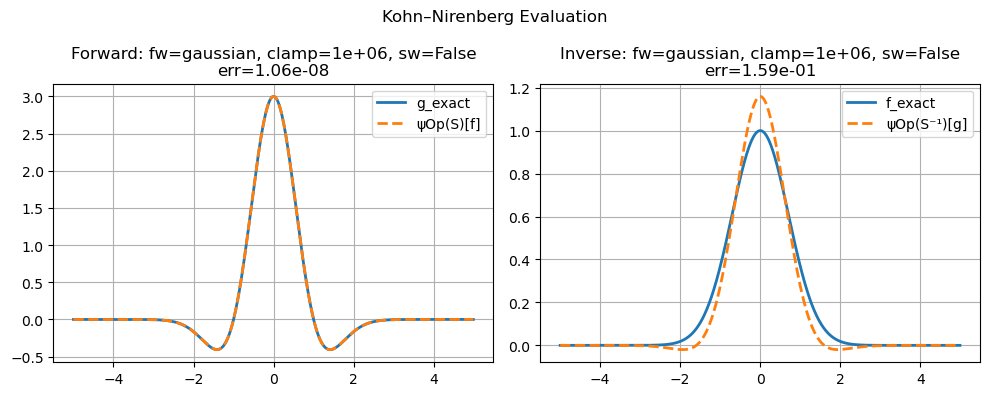

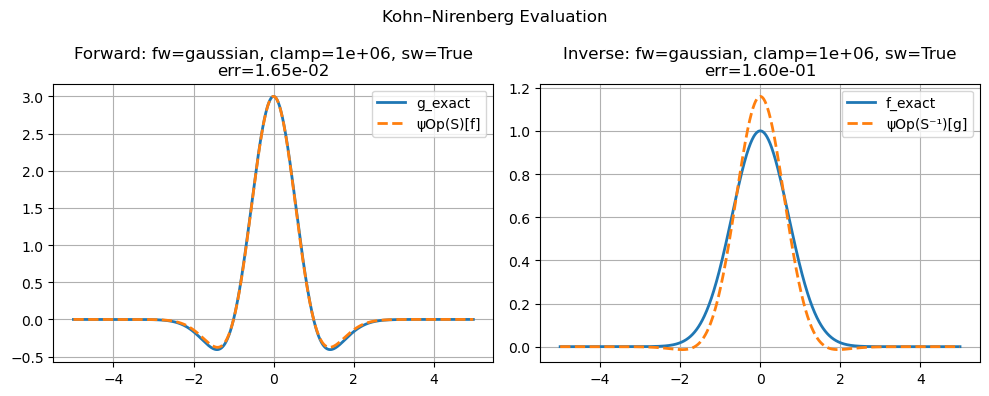

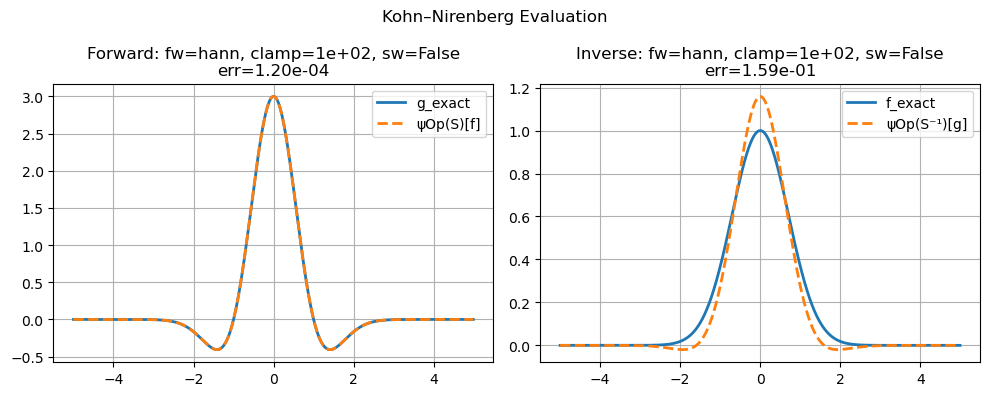

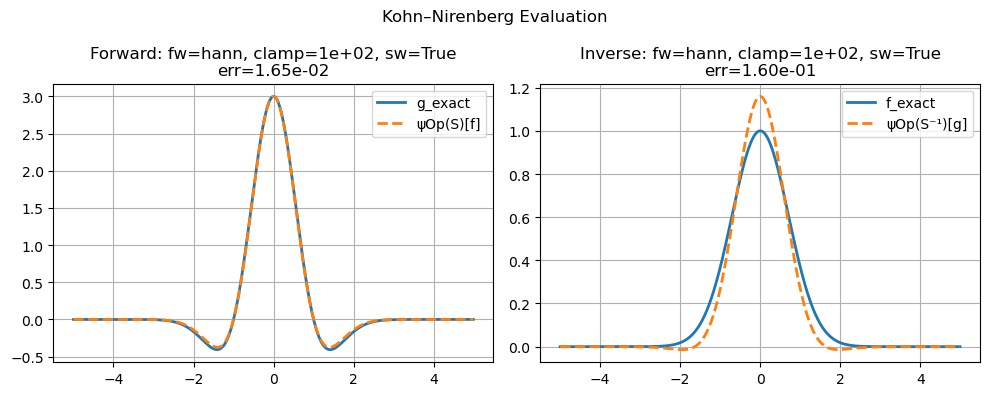

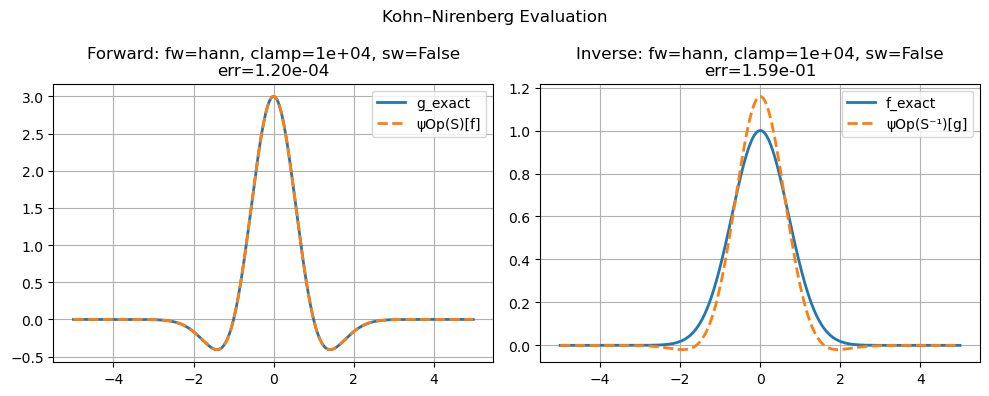

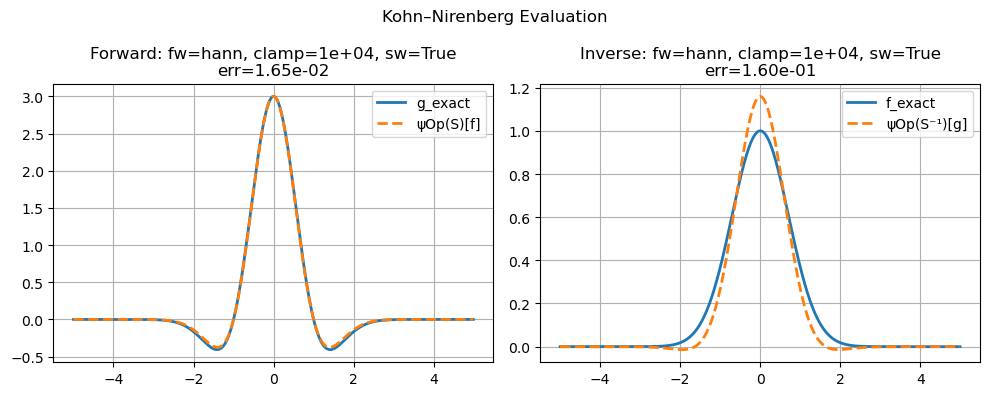

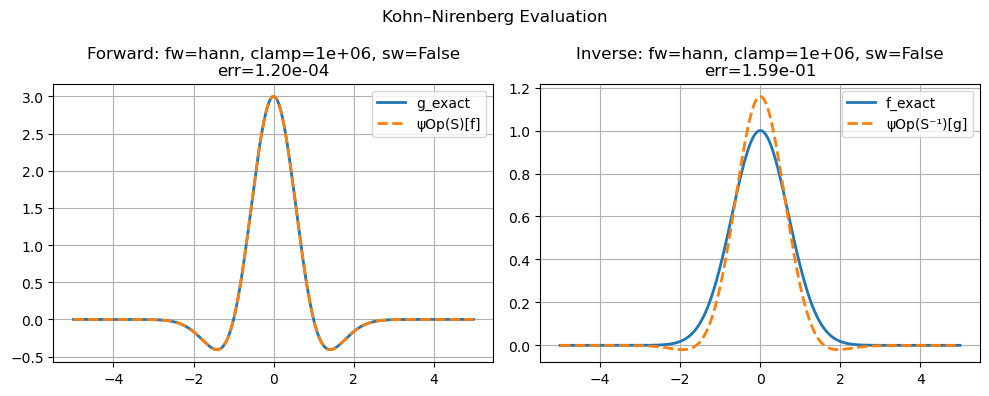

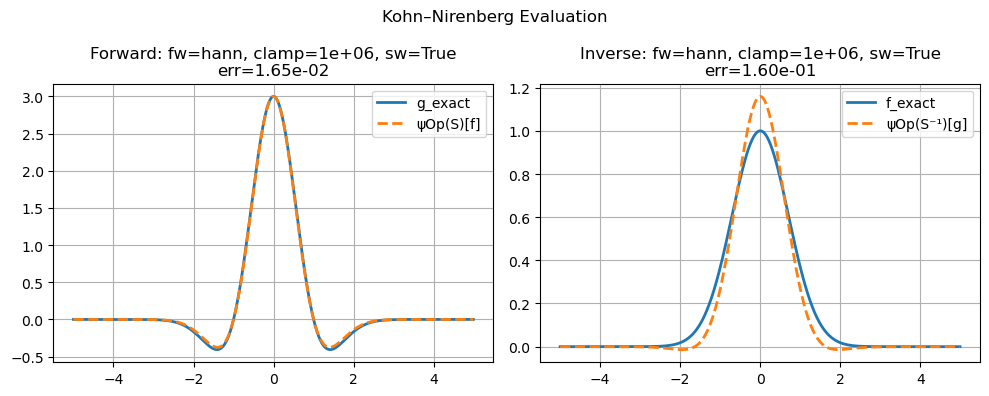


Summary of Relative Errors:
   FreqWin      Clamp   SpaceWin       ErrFwd       ErrInv
      None      1e+02      False     6.97e-10     1.59e-01
      None      1e+02       True     1.65e-02     1.60e-01
      None      1e+04      False     6.98e-10     1.59e-01
      None      1e+04       True     1.65e-02     1.60e-01
      None      1e+06      False     1.46e-09     1.59e-01
      None      1e+06       True     1.65e-02     1.60e-01
  gaussian      1e+02      False     1.06e-08     1.59e-01
  gaussian      1e+02       True     1.65e-02     1.60e-01
  gaussian      1e+04      False     1.06e-08     1.59e-01
  gaussian      1e+04       True     1.65e-02     1.60e-01
  gaussian      1e+06      False     1.06e-08     1.59e-01
  gaussian      1e+06       True     1.65e-02     1.60e-01
      hann      1e+02      False     1.20e-04     1.59e-01
      hann      1e+02       True     1.65e-02     1.60e-01
      hann      1e+04      False     1.20e-04     1.59e-01
      hann      1e+04      

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import Eq, symbols, Function
from itertools import product

# --- Define symbols and dummy equation ---
x, xi = symbols('x xi', real=True)
u = Function('u')(x)
equation = Eq(psiOp(x**2 + xi**2 + 1, u), 0)

# --- Initialize the solver ---
solver = PDESolver(equation)
L = 10
N = 1024
solver.setup(Lx=L, Nx=N)

# --- Define test input and target output ---
x_grid = solver.x_grid
f_exact = np.exp(-x_grid**2)
g_exact = 3 * (1 - x_grid**2) * f_exact

# --- Define the symbol and its inverse ---
def S(x, xi):
    return x**2 + xi**2 + 1

def S_inv(x, xi):
    return 1.0 / (S(x, xi) + 1e-10)

# --- Parameter combinations to test ---
freq_windows = [None, 'gaussian', 'hann']
clamp_values = [1e2, 1e4, 1e6]
space_windows = [False, True]

combinations = list(product(freq_windows, clamp_values, space_windows))

# --- Store errors for analysis ---
results = []

# --- Loop over parameter configurations ---
for i, (fw, clamp, sw) in enumerate(combinations):

    label = f"fw={fw}, clamp={clamp:.0e}, sw={sw}"

    # --- Apply operator ψOp(S)[f] ---
    g_approx = solver.kohn_nirenberg_fft(f_exact, symbol_func=S,
                                         freq_window=fw,
                                         clamp=clamp,
                                         space_window=sw)

    # --- Compute forward error ---
    err_forward = np.linalg.norm(g_exact - g_approx) / np.linalg.norm(g_exact)

    # --- Apply inverse ψOp(S⁻¹)[g] ---
    f_approx = solver.kohn_nirenberg_fft(g_approx, symbol_func=S_inv,
                                         freq_window=fw,
                                         clamp=clamp,
                                         space_window=sw)

    # --- Compute inverse error ---
    err_inverse = np.linalg.norm(f_exact - f_approx) / np.linalg.norm(f_exact)

    # --- Save results ---
    results.append((fw, clamp, sw, err_forward, err_inverse))

    # --- Plot results for this configuration ---
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(x_grid, g_exact, label='g_exact', lw=2)
    plt.plot(x_grid, g_approx, '--', label='ψOp(S)[f]', lw=2)
    plt.title(f"Forward: {label}\nerr={err_forward:.2e}")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(x_grid, f_exact, label='f_exact', lw=2)
    plt.plot(x_grid, f_approx, '--', label='ψOp(S⁻¹)[g]', lw=2)
    plt.title(f"Inverse: {label}\nerr={err_inverse:.2e}")
    plt.grid(True)
    plt.legend()

    plt.suptitle("Kohn–Nirenberg Evaluation")
    plt.tight_layout()
    plt.show()

# --- Summary Table ---
print("\nSummary of Relative Errors:")
print(f"{'FreqWin':>10} {'Clamp':>10} {'SpaceWin':>10} {'ErrFwd':>12} {'ErrInv':>12}")
for fw, clamp, sw, err1, err2 in results:
    print(f"{str(fw):>10} {clamp:10.0e} {str(sw):>10} {err1:12.2e} {err2:12.2e}")



*********************************
* Partial differential equation *
*********************************

     ⎛ 1.5    2      ⎞    
psiOp⎝x    + ξ , u(x)⎠ = 0

********************
* Equation parsing *
********************


Equation rewritten in standard form: psiOp(x**1.5 + xi**2, u(x))
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: psiOp(x**1.5 + xi**2, u(x))
Analyzing term: psiOp(x**1.5 + xi**2, u(x))
  --> Classified as pseudo linear term (psiOp)
Final linear terms: {}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(1, x**1.5 + xi**2)]
Source terms: []
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

symbol = 
 1.5    2
x    + ξ 
For psiOp, please use the interactive_symbol_analysis method separately


<lambdifygenerated-60>:2: RuntimeWarning: invalid value encountered in power
  return x**1.5 + xi**2
/tmp/ipykernel_14968/28638540.py:23: RuntimeWarning: invalid value encountered in sqrt
  return (xi**2 + x*x**(1/2) )


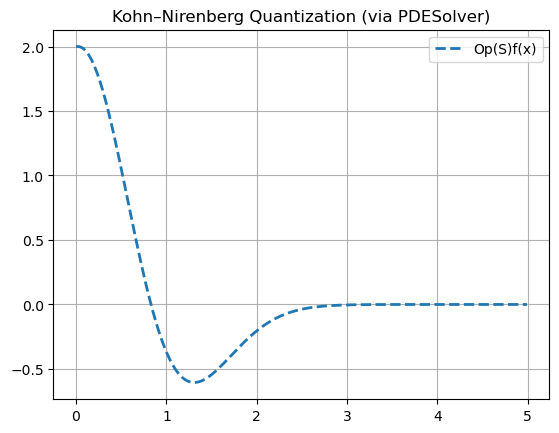

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import Eq, symbols, Function

# --- Dummy Equation for Solver Initialization ---
x, xi = symbols('x xi', real=True)
u = Function('u')(x)

equation = Eq(psiOp((xi**2 + x*x**(1/2)) , u), 0)

# --- Initialize Solver ---
solver = PDESolver(equation)
L = 10
N = 1024
solver.setup(Lx=L, Nx=N)

# --- Test Function and Target ---
x_grid = solver.x_grid
f_vals = np.exp(-x_grid**2)

# --- Symbol of the Pseudo-Op ---
def S(x, xi):
    return (xi**2 + x*x**(1/2) )

# --- Apply Pseudo-Operator ---
g_approx = solver.kohn_nirenberg_fft(f_vals, symbol_func=S)

# --- Relative Error ---

# --- Display Results ---
plt.plot(x_grid, g_approx, '--', label='Op(S)f(x)', lw=2)
plt.legend()
plt.grid(True)
plt.title("Kohn–Nirenberg Quantization (via PDESolver)")
plt.show()
